# Buổi 13 — Feature engineering và chống rò rỉ

**Một câu:** feature cho thời điểm cần dự báo chỉ được dùng thứ đã có trong tay lúc ra dự báo; shift trước rồi mới rolling, Tết tính
từ lịch âm, bài kiểm cắt tương lai, dùng bản dự báo thời tiết thay cho nhiệt độ thật đều là cách giữ đúng nguyên tắc đó.

Tình huống: doanh thu một cửa hàng bán lẻ trực tuyến ở Anh (2009–2011), lượt xem Wikipedia tiếng Việt quanh Tết, tải điện Texas 24 giờ
tới cùng nhiệt độ Dallas. Ta dựng bộ 41 feature, tự viết bài kiểm tìm rò rỉ, rồi đo cái giá khi lỡ dùng nhiệt độ thật.

| Phần | Câu hỏi |
|---|---|
| 1 | Feature nào được dùng, feature nào không? |
| 2 | Viết lag và rolling thế nào để không nhìn trộm? |
| 3 | Mã hoá thứ, mùa vụ năm và Tết âm lịch ra sao? |
| 4 | Ba kiểu rò rỉ nào ẩn trong "tính trên cả chuỗi"? |
| 5 | Làm sao để máy tự tìm ra rò rỉ? |
| 6 | Nhiệt độ thật hay nhiệt độ dự báo: rò rỉ đắt bao nhiêu? |

## 0. Dữ liệu

**Bộ dữ liệu Online Retail II.** Mọi **dòng hoá đơn** của một cửa hàng bán quà tặng trực tuyến ở Anh từ 1/12/2009 tới 9/12/2011, khách chủ yếu là
cửa hàng bán buôn — 1.067.371 dòng. Tệp Excel có hai trang tính (`Year 2009-2010`, `Year 2010-2011`), mỗi dòng là **một
mã hàng trên một hoá đơn**. Hoá đơn huỷ có số bắt đầu bằng `C` và số lượng âm.

Nguồn: Chen, D. (2012). Online Retail II [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CG6D. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `Invoice` | số hoá đơn; bắt đầu bằng `C` là hoá đơn huỷ |
| `StockCode` | mã hàng |
| `Quantity` | số lượng trên dòng này (âm khi trả hàng) |
| `InvoiceDate` | ngày giờ lập hoá đơn |
| `Price` | đơn giá, bảng Anh (£) |
| `Customer ID`, `Country` | mã khách (nhiều dòng để trống) và nước của khách |

**Bộ dữ liệu Wikimedia Pageviews — Wikipedia tiếng Việt.** Số **lượt xem mỗi ngày** trên Wikipedia tiếng Việt 2016–2025, do Wikimedia đếm (chỉ người thật — `agent=user`, bỏ bot
đã nhận diện). Hai tệp JSON: bài "Tết Nguyên Đán" (`wikipedia-vi-tet`) và tổng lượt xem cả trang tiếng Việt
(`wikipedia-vi-tong`). Mỗi phần tử của danh sách `items` là **một ngày**.

Nguồn: Wikimedia Foundation, Pageviews API (truy cập 2026-09-17); và 1 tệp cùng họ. Giấy phép CC0 1.0.

| Cột | Nghĩa |
|---|---|
| `timestamp` | ngày, dạng `2016010100` (năm, tháng, ngày, giờ 00) |
| `views` | số lượt xem trong ngày |

**Bộ dữ liệu EIA-930 Hourly Electric Grid Monitor — BALANCE.** Cơ quan Thông tin Năng lượng Mỹ (EIA) thu từ mọi **vùng điều độ điện** (balancing authority — đơn vị giữ cân bằng cung
cầu điện trong một vùng, ví dụ PJM ở miền Đông, ERCOT ở Texas) **nhu cầu điện mỗi giờ**, dự báo ngày hôm trước của chính họ,
và sản lượng theo nguồn. Mỗi tệp là sáu tháng, mỗi dòng là **một giờ của một vùng**. Mốc giờ là **cuối giờ**: dòng 01:00 là
lượng điện của giờ 00:00–01:00.

Nguồn: Source: U.S. Energy Information Administration, Form EIA-930 Hourly Electric Grid Monitor (truy cập 2026-09-17); và 1 tệp cùng họ. Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `Balancing Authority` | mã vùng điều độ, ví dụ `PJM`, `ERCO` (ERCOT) |
| `UTC Time at End of Hour` | mốc giờ UTC, là **cuối** giờ đo |
| `Demand (MW)` | nhu cầu điện trung bình trong giờ (MW) — thứ cần dự báo |
| `Demand Forecast (MW)` | dự báo ngày hôm trước của chính vùng điều độ |

**Bộ dữ liệu Open-Meteo Previous Runs — Dallas 2024.** Nhiệt độ **theo giờ** năm 2024 tại Dallas (Texas), đặt cạnh nhau: nhiệt độ **thật** và nhiệt độ mà mô hình thời tiết
đã **dự báo** trước 1 ngày và trước 3 ngày cho đúng giờ đó (Open-Meteo lưu lại các lần chạy cũ). Đây là thứ một mô hình dự
báo tải điện thật sự có trong tay lúc ra dự báo. Tệp CSV có 3 dòng đầu là thông tin điểm lưới; giờ theo **UTC**.

Nguồn: Weather data by Open-Meteo.com (https://open-meteo.com/), Previous Runs API. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `time` | giờ, **UTC** |
| `temperature_2m (°C)` | nhiệt độ thật ở độ cao 2 m |
| `temperature_2m_previous_day1 (°C)` | nhiệt độ cho giờ này, dự báo từ **1 ngày trước** |
| `temperature_2m_previous_day3 (°C)` | nhiệt độ cho giờ này, dự báo từ **3 ngày trước** |

Ô dưới tải dữ liệu (137 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "uci-online-retail-ii": ("572e36277c2390fbfde10664750731e0a86f55e33470d91919085f0408e67bfb", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-online-retail-ii/online+retail+ii.zip",
        "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip",
    ]),
    "wikipedia-vi-tet": ("8f9e15ea30553c66999c204119a99dd973c2c130bdd2e21acbfd642f0db9ca4e", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/wikipedia-vi-tet/tet-nguyen-dan-2016-2025.json",
        "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/vi.wikipedia/all-access/user/T%E1%BA%BFt_Nguy%C3%AAn_%C4%90%C3%A1n/daily/2016010100/2025123100",
    ]),
    "wikipedia-vi-tong": ("481d604d1b581efcb76c4a86d1dc6e5547271c6b8e2a772bcc53719b1fa1c3f3", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/wikipedia-vi-tong/vi-wikipedia-tong-2016-2025.json",
        "https://wikimedia.org/api/rest_v1/metrics/pageviews/aggregate/vi.wikipedia/all-access/user/daily/2016010100/2025123100",
    ]),
    "eia930-balance-2024-h1": ("26768c495c3ba987e29d79df2e40d4e741f9dbcff086f53c12ff774465756a10", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/eia930-balance-2024-h1/EIA930_BALANCE_2024_Jan_Jun.csv",
        "https://www.eia.gov/electricity/gridmonitor/sixMonthFiles/EIA930_BALANCE_2024_Jan_Jun.csv",
    ]),
    "eia930-balance-2024-h2": ("a602a8e577cfdd2fa3083413eaa4dd8ba7f0d2b26a2986f8f6d22917465ea49f", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/eia930-balance-2024-h2/EIA930_BALANCE_2024_Jul_Dec.csv",
        "https://www.eia.gov/electricity/gridmonitor/sixMonthFiles/EIA930_BALANCE_2024_Jul_Dec.csv",
    ]),
    "open-meteo-dallas-du-bao-luu-2024": ("5c7b56f9f713647e61b80a63a078150093598fdf8effdddf075898f7f04340fd", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/open-meteo-dallas-du-bao-luu-2024/open-meteo-dallas-du-bao-luu-2024.csv",
        "https://previous-runs-api.open-meteo.com/v1/forecast?latitude=32.7767&longitude=-96.797&start_date=2024-01-01&end_date=2024-12-31&hourly=temperature_2m,temperature_2m_previous_day1,temperature_2m_previous_day3&timezone=UTC&format=csv",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import io
import json
import math
import warnings
import zipfile
from datetime import date

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.simplefilter("ignore")

# Bán lẻ: hoá đơn → doanh thu theo ngày. Excel ~1 triệu dòng đọc mất cỡ một phút, nên lưu bản theo ngày cạnh tệp tải về.
tep = lay("uci-online-retail-ii")
ban_ngay = tep.parent / "online-retail-ii-doanh-thu-ngay.parquet"
if not ban_ngay.exists():
    with zipfile.ZipFile(tep) as z:
        xlsx = io.BytesIO(z.read("online_retail_II.xlsx"))
    hd = pd.concat([pd.read_excel(xlsx, sheet_name=s, usecols=["Quantity", "InvoiceDate", "Price"])
                    for s in ("Year 2009-2010", "Year 2010-2011")])
    hd = hd[(hd["Quantity"] > 0) & (hd["Price"] > 0)]                 # bỏ hoá đơn huỷ, trả hàng
    ngay = (hd["Quantity"] * hd["Price"]).groupby(pd.to_datetime(hd["InvoiceDate"]).dt.normalize()).sum()
    pd.DataFrame({"doanh_thu": ngay.asfreq("D")}).to_parquet(ban_ngay)
    del hd, xlsx
y = pd.read_parquet(ban_ngay)["doanh_thu"].ffill()                     # ngày nghỉ (không hoá đơn) lấy số hôm trước

muc = json.loads(lay("wikipedia-vi-tong").read_text(encoding="utf-8"))["items"]
wiki = pd.Series([m["views"] for m in muc], index=pd.to_datetime([m["timestamp"][:8] for m in muc], format="%Y%m%d"),
                 name="luot_xem").sort_index()

eia = pd.concat([pd.read_csv(lay(t), usecols=["Balancing Authority", "UTC Time at End of Hour", "Demand (MW)",
                                             "Demand (MW) (Adjusted)"])
                 for t in ("eia930-balance-2024-h1", "eia930-balance-2024-h2")])


def chuoi_tai(vung="ERCO", cot="Demand (MW)"):
    d = eia[eia["Balancing Authority"] == vung]
    s = pd.Series(pd.to_numeric(d[cot], errors="coerce").to_numpy(),
                  index=pd.to_datetime(d["UTC Time at End of Hour"], format="%m/%d/%Y %I:%M:%S %p")).sort_index()
    return s[~s.index.duplicated()].asfreq("h")


tt = pd.read_csv(lay("open-meteo-dallas-du-bao-luu-2024"), skiprows=3)
tt.columns = ["time", "nhiet_do_that", "du_bao_1_ngay", "du_bao_3_ngay"]
tt = tt.set_index(pd.to_datetime(tt.pop("time")))
print(f"bán lẻ {len(y)} ngày ({y.index[0]:%d/%m/%Y} → {y.index[-1]:%d/%m/%Y}) | Wikipedia {len(wiki):,} ngày | "
      f"ERCOT {len(chuoi_tai()):,} giờ | nhiệt độ Dallas {len(tt):,} giờ")

## 1. Feature hợp lệ là thứ đã có trong tay lúc ra dự báo

**Vấn đề.** Lịch sử cho ta mọi con số, kể cả những số mà lúc dự báo thật chưa xảy ra. Đưa nhầm một số như thế vào feature thì backtest
đẹp, dùng thật thì sập.

> **tầm dự báo $h$** · *forecast horizon*
>
> - **Là gì:** số bước từ lúc ra dự báo tới thời điểm cần dự báo.
> - **Ví dụ:** chiều thứ Hai dự báo doanh thu thứ Ba: $h$ = 1 ngày; dự báo tải điện giờ này ngày mai: $h$ = 24 giờ.
> - **Để làm gì:** quyết định dữ liệu nào đã có: feature cho $y_{t+h}$ chỉ dùng số liệu tới $t$.

> **rò rỉ (leakage)** · *data leakage*
>
> - **Là gì:** feature chứa thông tin mà lúc ra dự báo chưa có.
> - **Ví dụ:** trung bình 3 ngày có tâm của thứ Ba dùng cả doanh thu thứ Tư.
> - **Để làm gì:** phát hiện để loại: rò rỉ làm backtest đẹp giả, dùng thật thì sập.

> **biết trước bao lâu** · *availability, lead time*
>
> - **Là gì:** feature có trong tay trước thời điểm cần dự báo bao lâu. Mỗi feature hợp lệ thuộc một trong ba nhóm: lịch (mãi mãi), kế hoạch đã công bố (từ lúc công bố), quá khứ của chuỗi (tới $t$).
> - **Ví dụ:** thứ của ngày 1/1/2030 biết ngay bây giờ; dự báo mưa ngày mai biết từ lúc đài công bố; doanh thu hôm qua biết từ tối qua.
> - **Để làm gì:** bảng "biết trước bao lâu" nộp kèm mô hình để người khác soát rò rỉ mà không cần đọc code.

**Lý do.** Nguyên tắc duy nhất: feature cho $y_{t+h}$ chỉ dùng thông tin có thật tại $t$. Mọi feature hợp lệ rơi vào một trong ba nhóm
— lịch, kế hoạch đã công bố, quá khứ của chuỗi. Không xếp được vào nhóm nào là đáng ngờ.

**Kết quả.** Tối thứ Hai 7/6/2010 dự báo doanh thu thứ Ba ($h$ = 1), rồi phân loại vài tên feature:

In [ ]:
t = pd.Timestamp("2010-06-07")
muc_tieu = t + pd.Timedelta(days=1)
print(f"ngày cần dự báo {muc_tieu:%d/%m/%Y}, thứ (0 = thứ Hai) = {muc_tieu.dayofweek}: lịch, biết trước mãi mãi")
print(f"trung bình doanh thu đã biết tới {t:%d/%m}: {y[:t].mean():,.0f} ({len(y[:t])} ngày)")
print(f"trung bình cả chuỗi                : {y.mean():,.0f} (gồm {len(y[muc_tieu:])} ngày chưa xảy ra)")


def bang_biet_truoc(cac_cot):
    # xếp mỗi feature vào một nhóm theo TÊN cột: "vô hạn" (lịch), "t-h" (quá khứ của chuỗi), "kế hoạch" (đã công bố)
    hang = []
    for cot in cac_cot:
        if cot.startswith(("lag_", "tb_", "sd_", "min_", "max_", "q90_", "chenh_", "ty_le_")):
            loai = "t-h"
        elif cot.startswith(("du_bao_", "khuyen_mai")):
            loai = "kế hoạch"
        elif cot.endswith("_that"):
            loai = "KHÔNG BIẾT TRƯỚC"
        else:
            loai = "vô hạn"
        hang.append({"feature": cot, "biết trước": loai})
    return pd.DataFrame(hang)


print(bang_biet_truoc(["thu_sin", "so_ngay_toi_tet", "lag_7", "tb_28", "du_bao_1_ngay", "nhiet_do_that", "z_score"])
      .to_string(index=False))

Thứ của ngày mai đã biết; doanh thu thì chỉ có tới thứ Hai. Trung bình cả chuỗi (33.454) cao hơn hẳn trung bình 189 ngày đã biết (27.701), vì
gồm 550 ngày chưa xảy ra. Bảng phân loại chỉ đọc tên: `nhiet_do_that` bị gắn "KHÔNG BIẾT TRƯỚC", nhưng `z_score` lọt vào "vô hạn". Tên
sai thì bảng sai, nên tên cột phải nói đúng nguồn.

**Bài học.** Với mỗi feature hỏi "lúc ra dự báo tôi có nó chưa?", rồi ghi câu trả lời vào bảng biết trước nộp kèm mô hình.

## 2. Shift trước, rolling sau; lag nhỏ nhất phải ≥ tầm dự báo

**Vấn đề.** Lag và rolling là feature mạnh nhất, cũng là chỗ rò rỉ hay gặp nhất: một dòng thiếu `shift` trông y hệt dòng đúng.

> **lag** · *lag feature*
>
> - **Là gì:** giá trị của chuỗi $k$ bước trước: `y.shift(k)`, tức `lag_k` của ngày $t$ là $y_{t-k}$.
> - **Ví dụ:** `lag_7` của thứ Hai 14/6 là doanh thu thứ Hai 7/6.
> - **Để làm gì:** feature mạnh nhất cho chuỗi có quán tính và mùa vụ tuần, với điều kiện $k \ge h$.
>
> 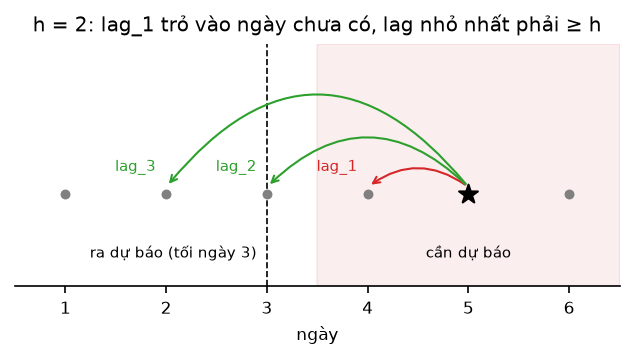

> **rolling** · *rolling window statistic*
>
> - **Là gì:** thống kê (trung bình, độ lệch chuẩn, lớn nhất…) trên cửa sổ $w$ điểm gần nhất: `y.rolling(w).mean()`.
> - **Ví dụ:** doanh thu 10, 12, 8: trung bình 3 ngày là 10.
> - **Để làm gì:** tóm mức gần đây của chuỗi, ít nhiễu hơn một lag lẻ.
>
> 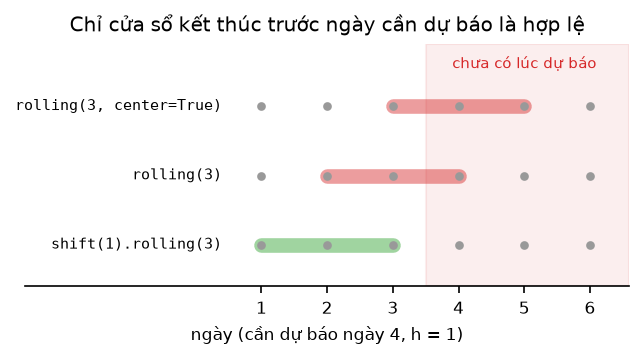

**Lý do.** `y.rolling(3)` ở ngày $t$ gồm $y_{t-2}, y_{t-1}, y_t$ — có chính $y_t$ đang cần đoán; `center=True` lấy thêm $y_{t+1}$. Lùi chuỗi
$h$ bước trước (`y.shift(h)`) thì cửa sổ kết thúc ở $t-h$. Lag cũng vậy: với $h$ = 2, tối ngày 3 dự báo ngày 5 thì chưa có số ngày 4,
nên `lag_1` không dùng được.

**Kết quả.** Sáu ngày doanh thu, ba cách viết "trung bình 3 ngày" ($h$ = 1) và hai lag ($h$ = 2):

In [ ]:
v = pd.Series([10, 12, 8, 14, 20, 16], index=range(1, 7), dtype=float)
print(pd.DataFrame({"y": v, "center=True": v.rolling(3, center=True).mean(), "rolling(3)": v.rolling(3).mean(),
                    "shift(1).rolling(3)": v.shift(1).rolling(3).mean(), "lag_1": v.shift(1), "lag_2": v.shift(2)})
      .round(2).rename_axis("ngày").to_string())

Ngày 4: bản có tâm ra 14 (dùng ngày 5), bản không shift ra 11,33 (có chính ngày 4); chỉ bản shift ra 10 = (10 + 12 + 8)/3, toàn số
đã biết tối ngày 3. Với $h$ = 2, `lag_1` của ngày 5 là 14 — số của ngày 4, chưa có lúc dự báo.

Trên dữ liệu thật: lấy 120 ngày bán lẻ đầu, tính trung bình 7 ngày hai kiểu, rồi cắt dữ liệu ở ngày thứ 90 và tính lại.

In [ ]:
nho = y.iloc[:120]
moc = nho.index[90]
cat = nho[nho.index <= moc]
fig, truc = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, ham, ten in ((truc[0], lambda s: s.shift(1).rolling(7).mean(), "shift(1).rolling(7): nhân quả"),
                     (truc[1], lambda s: s.rolling(7, center=True, min_periods=1).mean(), "rolling(7, center=True): RÒ RỈ")):
    du, lai = ham(nho), ham(cat)
    lech = np.nanmax(np.abs((du.reindex(lai.index) - lai).to_numpy()))
    ax.plot(nho / 1e3, color="0.7", lw=0.7, label="chuỗi gốc")
    ax.plot(du / 1e3, lw=1.6, label="tính trên dữ liệu đầy đủ")
    ax.plot(lai / 1e3, "--", lw=1.6, label="tính lại sau khi cắt")
    ax.axvline(moc, color="k", lw=1)
    ax.set_title(f"{ten} — lệch lớn nhất {lech:,.0f}", fontsize=9)
    print(f"{ten}: lệch lớn nhất sau khi cắt {lech:,.1f}")
    ax.legend(fontsize=7)
truc[0].set_ylabel("doanh thu (nghìn)")
plt.show()


def feature_tre(y, tam=1, cac_lag=(1, 2, 3, 7, 14, 28), cac_cua_so=(7, 28)):
    # lag nhỏ nhất ≥ tầm dự báo; mọi rolling tính trên chuỗi đã lùi `tam` bước
    f = pd.DataFrame(index=y.index)
    tre = y.shift(tam)
    for lag in cac_lag:
        f[f"lag_{lag}"] = y.shift(max(lag, tam))
    for w in cac_cua_so:
        f[f"tb_{w}"] = tre.rolling(w).mean()
        f[f"sd_{w}"] = tre.rolling(w).std()
        f[f"min_{w}"] = tre.rolling(w).min()
        f[f"max_{w}"] = tre.rolling(w).max()
        f[f"q90_{w}"] = tre.rolling(w).quantile(0.9)
    f["chenh_1"] = tre.diff()
    f["ty_le_tb7_tb28"] = f["tb_7"] / f["tb_28"]
    return f


print("feature_tre:", feature_tre(y).shape[1], "cột")

Bản shift trùng khít với chính nó sau khi cắt (lệch 0). Bản có tâm tách ra ngay trước vạch cắt, lệch tới 5.113: đó là phần nó đã
biết về sau vạch. Hàm `feature_tre` gom 18 cột lag và rolling viết theo đúng quy tắc.

**Bài học.** Lag nhỏ nhất ≥ $h$; mọi rolling tính trên `y.shift(h)`. Rolling không shift và `center=True` chỉ để mô tả lịch sử, không làm
feature.

## 3. Lịch biết trước mãi mãi, nhưng phải mã hoá đúng: vòng tròn, sóng, lịch âm

**Vấn đề.** Lịch không bao giờ rò rỉ, nhưng mã hoá sai thì mô hình không học được. Thứ Hai là 0, Chủ nhật là 6 dù hai ngày kề nhau. Tết
mỗi năm rơi vào một ngày dương khác; ghi cứng Tết 2011 thì sai mọi năm còn lại.

> **mã hoá tuần hoàn** · *cyclical encoding*
>
> - **Là gì:** thay số thứ tự của một vòng lặp (thứ 0–6, tháng 1–12) bằng cặp sin, cos của góc $2\pi \cdot \text{số}/\text{chu kỳ}$, để hai đầu vòng nằm cạnh nhau.
> - **Ví dụ:** Chủ nhật (6) thành (−0,782; 0,623), thứ Hai (0) thành (0; 1): cách nhau 0,87, bằng khoảng cách giữa hai ngày kề bất kỳ.
> - **Để làm gì:** mô hình thấy Chủ nhật sát thứ Hai, tháng 12 sát tháng 1.
>
> 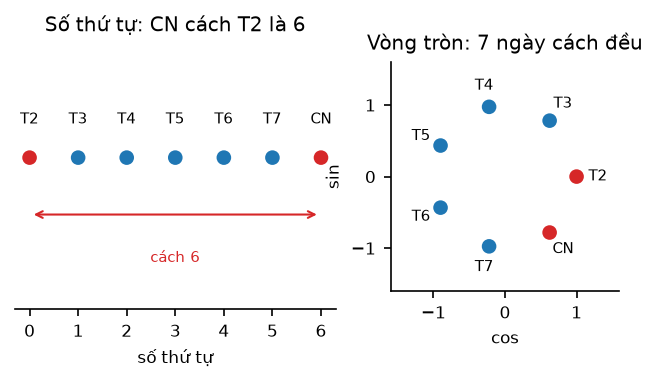

> **Fourier term** · *Fourier terms*
>
> - **Là gì:** $K$ cặp $\sin(2\pi i t/365{,}25)$, $\cos(2\pi i t/365{,}25)$ với $i$ = 1…$K$: sóng lặp 1, 2, …, $K$ lần mỗi năm. Cộng có trọng số thì vẽ được mọi hình mùa vụ trơn.
> - **Ví dụ:** $K$ = 3: 6 cột thay cho 365 biến giả ngày trong năm.
> - **Để làm gì:** mùa vụ dài (năm, trên dữ liệu ngày) với ít cột; $K$ lớn bắt được đỉnh hẹp nhưng dễ học thuộc nhiễu.
>
> 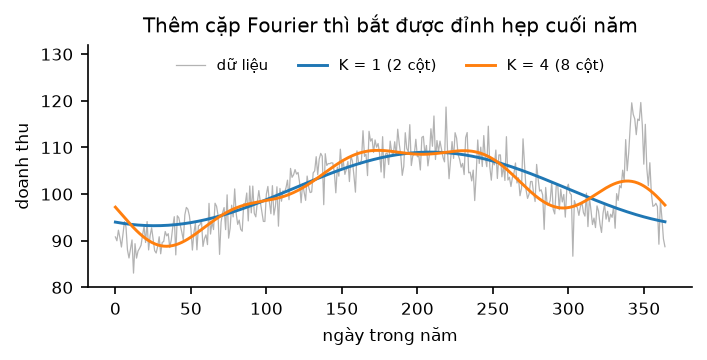

> **lịch âm, sóc** · *lunisolar calendar, new moon*
>
> - **Là gì:** lịch âm đếm tháng theo tuần trăng; sóc là lúc trăng mới, ngày chứa sóc là mùng 1. Ngày sóc tính theo giờ địa phương, nên Việt Nam (UTC+7) và Trung Quốc (UTC+8) đôi khi có mùng 1 khác nhau.
> - **Ví dụ:** Tết 2007: sóc rơi sát nửa đêm, trước 0 giờ ở Hà Nội, sau 0 giờ ở Bắc Kinh; Việt Nam đón mùng 1 ngày 17/2, Trung Quốc ngày 18/2.
> - **Để làm gì:** tính đúng ngày Tết cho mọi năm, thay vì ghi cứng một ngày.

**Lý do.** Đặt các ngày lên vòng tròn bằng cặp sin, cos thì khoảng cách đúng; phải dùng cả cặp, vì chỉ sin thì hai thời điểm khác nhau
trùng giá trị. Mùa vụ năm dùng vài cặp Fourier. Tết tính từ lịch âm (thuật toán thiên văn của Meeus): tìm các ngày sóc, lấy tháng 11 âm
là tháng chứa đông chí, rồi đếm tháng — ở múi giờ Việt Nam.

**Kết quả.** Cặp sin/cos của ba ngày cuối – đầu tuần:

In [ ]:
so = np.array([5, 6, 0])                                            # thứ Bảy, Chủ nhật, thứ Hai
vong = np.column_stack([np.sin(2 * np.pi * so / 7), np.cos(2 * np.pi * so / 7)])
print(pd.DataFrame(vong.round(3), index=["thứ Bảy", "Chủ nhật", "thứ Hai"], columns=["sin", "cos"]))
print(f"khoảng cách Chủ nhật – thứ Hai {np.linalg.norm(vong[1] - vong[2]):.3f}, Chủ nhật – thứ Bảy {np.linalg.norm(vong[1] - vong[0]):.3f}")


# ---- Lịch âm Việt Nam (Meeus, Astronomical Algorithms ch. 25, 49); mui_gio = 7 cho Việt Nam, 8 cho Trung Quốc ----
def jd_tu_ngay(dd, mm, yy):                                          # số ngày Julius của một ngày dương
    a = (14 - mm) // 12
    y_, m = yy + 4800 - a, mm + 12 * a - 3
    jd = dd + (153 * m + 2) // 5 + 365 * y_ + y_ // 4 - y_ // 100 + y_ // 400 - 32045
    if jd < 2299161:
        jd = dd + (153 * m + 2) // 5 + 365 * y_ + y_ // 4 - 32083
    return jd


def ngay_tu_jd(jd):
    if jd > 2299160:
        a = jd + 32044
        b = (4 * a + 3) // 146097
        c = a - (b * 146097) // 4
    else:
        b, c = 0, jd + 32082
    d = (4 * c + 3) // 1461
    e = c - (1461 * d) // 4
    m = (5 * e + 2) // 153
    return e - (153 * m + 2) // 5 + 1, m + 3 - 12 * (m // 10), b * 100 + d - 4800 + m // 10


def _soc(k):                                                         # thời điểm sóc thứ k tính từ 1900 (JD, UTC)
    t = k / 1236.85
    t2, t3 = t * t, t * t * t
    dr = math.pi / 180
    jd1 = 2415020.75933 + 29.53058868 * k + 0.0001178 * t2 - 0.000000155 * t3
    jd1 += 0.00033 * math.sin((166.56 + 132.87 * t - 0.009173 * t2) * dr)
    m = 359.2242 + 29.10535608 * k - 0.0000333 * t2 - 0.00000347 * t3
    mpr = 306.0253 + 385.81691806 * k + 0.0107306 * t2 + 0.00001236 * t3
    f = 21.2964 + 390.67050646 * k - 0.0016528 * t2 - 0.00000239 * t3
    c1 = (0.1734 - 0.000393 * t) * math.sin(m * dr) + 0.0021 * math.sin(2 * dr * m)
    c1 -= 0.4068 * math.sin(mpr * dr) + 0.0161 * math.sin(2 * dr * mpr)
    c1 -= 0.0004 * math.sin(3 * dr * mpr)
    c1 += 0.0104 * math.sin(2 * dr * f) - 0.0051 * math.sin((m + mpr) * dr)
    c1 -= 0.0074 * math.sin((m - mpr) * dr) + 0.0004 * math.sin((2 * f + m) * dr)
    c1 -= 0.0004 * math.sin((2 * f - m) * dr) - 0.0006 * math.sin((2 * f + mpr) * dr)
    c1 += 0.0010 * math.sin((2 * f - mpr) * dr) + 0.0005 * math.sin((2 * mpr + m) * dr)
    if t < -11:
        dt = 0.001 + 0.000839 * t + 0.0002261 * t2 - 0.00000845 * t3 - 0.000000081 * t * t3
    else:
        dt = -0.000278 + 0.000265 * t + 0.000262 * t2
    return jd1 + c1 - dt


def _kinh_do_mat_troi(jdn):
    t = (jdn - 2451545.0) / 36525
    t2 = t * t
    dr = math.pi / 180
    m = 357.52910 + 35999.05030 * t - 0.0001559 * t2 - 0.00000048 * t * t2
    l0 = 280.46645 + 36000.76983 * t + 0.0003032 * t2
    dl = (1.914600 - 0.004817 * t - 0.000014 * t2) * math.sin(dr * m)
    dl += (0.019993 - 0.000101 * t) * math.sin(dr * 2 * m) + 0.000290 * math.sin(dr * 3 * m)
    lam = (l0 + dl) * dr
    return lam - math.pi * 2 * int(lam / (math.pi * 2))


def _cung_mat_troi(so_ngay, mui_gio):
    return int(_kinh_do_mat_troi(so_ngay - 0.5 - mui_gio / 24.0) / math.pi * 6)


def _ngay_soc(k, mui_gio):                                           # ngày (JD, giờ địa phương) chứa sóc thứ k
    return int(_soc(k) + 0.5 + mui_gio / 24.0)


def _thang_11(yy, mui_gio):                                          # mùng 1 tháng 11 âm: tháng chứa đông chí
    k = int((jd_tu_ngay(31, 12, yy) - 2415021) / 29.530588853)
    nm = _ngay_soc(k, mui_gio)
    if _cung_mat_troi(nm, mui_gio) >= 9:
        nm = _ngay_soc(k - 1, mui_gio)
    return nm


def _thang_nhuan(a11, mui_gio):
    k = int((a11 - 2415021.076998695) / 29.530588853 + 0.5)
    i = 1
    arc = _cung_mat_troi(_ngay_soc(k + i, mui_gio), mui_gio)
    while True:
        last = arc
        i += 1
        arc = _cung_mat_troi(_ngay_soc(k + i, mui_gio), mui_gio)
        if arc == last or i >= 14:
            break
    return i - 1


def am_sang_duong(ngay, thang, nam, nhuan=0, mui_gio=7):
    if thang < 11:
        a11, b11 = _thang_11(nam - 1, mui_gio), _thang_11(nam, mui_gio)
    else:
        a11, b11 = _thang_11(nam, mui_gio), _thang_11(nam + 1, mui_gio)
    k = int(0.5 + (a11 - 2415021.076998695) / 29.530588853)
    off = (thang - 11) % 12
    if b11 - a11 > 365:                                              # năm có tháng nhuận
        lech = _thang_nhuan(a11, mui_gio)
        if nhuan != 0 and thang != (lech - 2) % 12:
            return None
        if nhuan != 0 or off >= lech:
            off += 1
    dd, mm, yy = ngay_tu_jd(_ngay_soc(k + off, mui_gio) + ngay - 1)
    return date(yy, mm, dd)


def tet(nam, mui_gio=7):
    return am_sang_duong(1, 1, nam, 0, mui_gio)


def gio_to(nam, mui_gio=7):                                          # Giỗ Tổ: mùng 10 tháng 3 âm
    return am_sang_duong(10, 3, nam, 0, mui_gio)


def so_ngay_toi_tet(moc):                                            # tới mùng 1 Tết gần nhất (âm = đã qua Tết)
    moc_tet = pd.DatetimeIndex([pd.Timestamp(tet(n)) for n in sorted({d.year for d in moc} | {d.year + 1 for d in moc})])
    ra = []
    for d in moc:
        lech = (moc_tet - d).days.to_numpy()
        ra.append(int(lech[np.argmin(np.abs(lech))]))
    return pd.Series(ra, index=moc)


print("Tết lệch Việt Nam / Trung Quốc 2000–2035:", {n: (str(tet(n, 7)), str(tet(n, 8))) for n in range(2000, 2036) if tet(n, 7) != tet(n, 8)})
khop = sum(tet(n) == next(d for d, ten in holidays.country_holidays("VN", years=n).items() if ten == "Lunar New Year")
           for n in range(2000, 2036))
print(f"khớp thư viện holidays: {khop}/36 năm | Tết 2016–2025 rơi vào ngày thứ "
      f"{min(pd.Timestamp(tet(n)).dayofyear for n in range(2016, 2026))}–{max(pd.Timestamp(tet(n)).dayofyear for n in range(2016, 2026))} của năm dương")

Chủ nhật cách thứ Hai 0,868, đúng bằng cách thứ Bảy: bảy ngày nằm đều trên vòng tròn. Lịch âm tự viết khớp `holidays` cả 36 năm, và
chỉ lệch Trung Quốc ở 2007, 2030 — đúng hai năm sóc rơi sát nửa đêm. Tết 2016–2025 xê dịch từ ngày thứ 22 tới 47 của năm dương.

Giờ gom lịch, Fourier và Tết thành bộ feature, đo hiệu ứng Tết trên lượt xem Wikipedia, rồi so mô hình có và không có 5 feature Tết (hồi
quy tuyến tính, học 70% đầu, dự báo 1 ngày tới):

In [ ]:
def feature_lich(moc):
    f = pd.DataFrame(index=moc)
    f["thu"], f["ngay_trong_thang"], f["thang"] = moc.dayofweek, moc.day, moc.month
    f["tuan_trong_nam"] = moc.isocalendar().week.to_numpy()
    f["cuoi_tuan"] = (moc.dayofweek >= 5).astype(int)
    f["dau_thang"] = (moc.day <= 3).astype(int)
    f["cuoi_thang"] = moc.is_month_end.astype(int)
    f["thu_sin"], f["thu_cos"] = np.sin(2 * np.pi * moc.dayofweek / 7), np.cos(2 * np.pi * moc.dayofweek / 7)
    f["thang_sin"], f["thang_cos"] = np.sin(2 * np.pi * moc.month / 12), np.cos(2 * np.pi * moc.month / 12)
    le = holidays.country_holidays("VN", years=sorted({d.year for d in moc}))
    f["le_duong_lich"] = [int(d.date() in le and "Lunar" not in le.get(d.date(), "")) for d in moc]
    tet_con = so_ngay_toi_tet(moc)
    f["so_ngay_toi_tet"] = tet_con
    f["truoc_tet_7"] = ((tet_con > 0) & (tet_con <= 7)).astype(int)
    f["trong_tet_7"] = (tet_con.abs() <= 3).astype(int)
    f["sau_tet_7"] = ((tet_con < 0) & (tet_con >= -7)).astype(int)
    f["gio_to"] = [int(d.date() == gio_to(d.year)) for d in moc]
    return f


def feature_fourier(moc, chu_ky=365.25, k=3):
    t = (moc - moc[0]).days.to_numpy().astype(float)
    f = pd.DataFrame(index=moc)
    for i in range(1, k + 1):
        f[f"fourier_sin_{i}"] = np.sin(2 * np.pi * i * t / chu_ky)
        f[f"fourier_cos_{i}"] = np.cos(2 * np.pi * i * t / chu_ky)
    return f


def bo_feature(y, tam=1, k=3):
    return pd.concat([feature_tre(y, tam), feature_lich(y.index), feature_fourier(y.index, k=k)], axis=1)


def hoi_quy(X_hoc, y_hoc, X_kiem):                                  # hồi quy tuyến tính bình phương nhỏ nhất
    A = np.column_stack([np.ones(len(X_hoc)), np.asarray(X_hoc, float)])
    he_so = np.linalg.lstsq(A, np.asarray(y_hoc, float), rcond=None)[0]
    return np.column_stack([np.ones(len(X_kiem)), np.asarray(X_kiem, float)]) @ he_so


def mae_wiki(f, ty_le_hoc=0.7):                                      # MAE cả phần kiểm và MAE ±10 ngày quanh Tết
    bang = f.join(wiki.rename("muc_tieu").shift(-1)).dropna()
    cot = [c for c in bang.columns if c != "muc_tieu"]
    hoc, kiem = bang.iloc[:int(len(bang) * ty_le_hoc)], bang.iloc[int(len(bang) * ty_le_hoc):]
    sai = np.abs(hoi_quy(hoc[cot], hoc["muc_tieu"], kiem[cot]) - kiem["muc_tieu"].to_numpy(float))
    return len(cot), sai.mean(), sai[(so_ngay_toi_tet(kiem.index).abs() <= 10).to_numpy()].mean()


d = so_ngay_toi_tet(wiki.index)
quanh = d.abs() <= 15
hieu_ung = wiki[quanh].groupby(d[quanh]).mean() / wiki.mean()
print(f"lượt xem / mức trung bình: đáy {hieu_ung.min():.2f} vào ngày {hieu_ung.idxmin()} (0 = mùng 1, 1 = ngày trước mùng 1); "
      f"mùng 1: {hieu_ung[0]:.2f}, mùng 2: {hieu_ung[-1]:.2f}")

f_wiki = bo_feature(wiki)
khong_tet = f_wiki.drop(columns=[c for c in f_wiki.columns if "tet" in c or "gio_to" in c])
kq = pd.DataFrame([mae_wiki(khong_tet), mae_wiki(f_wiki)], columns=["số feature", "MAE cả năm", "MAE quanh Tết"],
                  index=["lag + lịch dương", "+ 5 feature Tết âm lịch"])
print(kq.round(0).astype(int).to_string())
print(f"cải thiện: cả năm {kq.iloc[1, 1] / kq.iloc[0, 1] - 1:+.1%}, quanh Tết {kq.iloc[1, 2] / kq.iloc[0, 2] - 1:+.1%}")

Lượt xem tụt còn 0,62 lần mức thường vào ngày trước mùng 1 (ngày tính theo giờ UTC) và 0,63 lần vào mùng 1. Thêm 5 feature Tết: cả năm chỉ tốt hơn 1,9% (132.137 → 129.680) vì Tết chiếm vài
phần trăm số ngày; quanh Tết tốt hơn 16,9% (167.769 → 139.478). Báo cải thiện trung bình cả năm thì feature này dễ bị loại oan.

**Bài học.** Lịch là nhóm feature an toàn nhất: thứ, tháng mã hoá bằng cả cặp sin/cos, mùa vụ dài bằng vài cặp Fourier, Tết tính từ lịch
âm ở UTC+7. Đo cải thiện ở vùng feature có tác dụng.

## 4. Trung bình, độ lệch chuẩn, nội suy tính trên cả chuỗi đều mang tương lai vào quá khứ

**Vấn đề.** Ngoài lag và rolling còn ba kiểu rò rỉ hay gặp: chuẩn hoá (z-score) toàn chuỗi, target encoding toàn chuỗi, điền chỗ thiếu từ
hai phía.

> **target encoding**
>
> - **Là gì:** thay một nhóm (thứ, mã hàng) bằng trung bình của biến mục tiêu trong nhóm đó.
> - **Ví dụ:** ngày lẻ thuộc nhóm A có doanh thu 10, 8, 20 → nhóm A mã hoá thành 12,67.
> - **Để làm gì:** biến nhóm nhiều giá trị thành một cột số; hợp lệ khi chỉ lấy trung bình các ngày trước $t$.

**Lý do.** Chung một gốc: một con số tính trên toàn bộ dữ liệu, kể cả phần tương lai, rồi đưa vào feature của từng ngày. Bản đúng chỉ dùng
các ngày trước $t$ (`shift(1)` rồi `expanding()` — trung bình từ đầu chuỗi tới hôm qua), hoặc học tham số chỉ trên phần học rồi cố định.

**Kết quả.** Cùng sáu ngày; ngày lẻ nhóm A, ngày chẵn nhóm B; ngày 3 bị mất số ở cột điền thiếu:

In [ ]:
nhom = pd.Series(["A", "B"] * 3, index=v.index)
co_lo = v.copy()
co_lo[3] = np.nan
print(pd.DataFrame({
    "y": v, "nhóm": nhom,
    "z toàn chuỗi": (v - v.mean()) / v.std(),
    "TB đã biết": v.shift(1).expanding().mean(),
    "TB nhóm toàn chuỗi": v.groupby(nhom).transform("mean"),
    "TB nhóm đã biết": v.groupby(nhom).transform(lambda s: s.shift(1).expanding().mean()),
    "điền hai phía": co_lo.interpolate(limit_direction="both"),
    "ffill": co_lo.ffill(),
}).round(2).rename_axis("ngày").to_string())
print(f"trung bình cả 6 ngày {v.mean():.2f}, độ lệch chuẩn {v.std():.2f}")

Mọi ô z đều dùng trung bình 13,33, đã gồm hai ngày cuối: ngày 1 "biết" mình thấp hơn mức chung tức là biết các ngày sau cao. Ngày 1
mang trung bình nhóm A 12,67, trong đó có số 20 của ngày 5. Điền hai phía ra 13 nhờ số 14 của ngày 4, còn `ffill` ra 12; rò rỉ này chỉ
lộ ở mép lỗ, những ngày không thiếu thì hai cột giống hệt.

**Bài học.** Trung bình, độ lệch chuẩn, trung bình nhóm chỉ học từ phần học hoặc từ quá khứ của từng dòng. `StandardScaler` `fit` trên
phần học rồi mới `transform` cả hai phần, không bao giờ `fit` trên cả tập rồi mới chia.

## 5. Cắt tương lai rồi tính lại: máy tìm ra rò rỉ, nếu bài kiểm viết đúng

**Vấn đề.** Không ai đọc hết code của 41 feature. Cần phép thử chạy được trên mọi hàm tạo feature.

> **kiểm nhiễu mục tiêu** · *target perturbation test*
>
> - **Là gì:** cộng nhiễu lớn vào $y$ từ một mốc (70% chuỗi) trở đi rồi tính lại feature; dòng nào lúc ra dự báo ($t - h$) còn trước mốc thì feature không được đổi.
> - **Ví dụ:** $h$ = 24 giờ và có `lag_1`: 23 dòng ngay sau mốc đổi theo, dù lúc dự báo cho chúng phần bị đổi chưa xảy ra → bị bắt.
> - **Để làm gì:** bắt lag nhỏ hơn tầm dự báo, lỗi mà bài kiểm cắt tương lai không thấy.
>
> 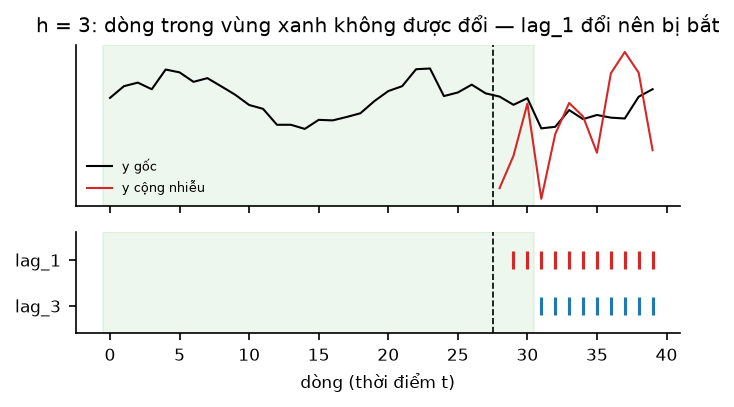

**Lý do.** Tính feature trên dữ liệu đầy đủ; cắt dữ liệu tại một mốc rồi tính lại; so mọi dòng trước mốc. Feature hợp lệ cho kết quả y
hệt, feature rò rỉ thì đổi vì từng thấy phần bị cắt. Bốn chi tiết quyết định bài kiểm có tác dụng: so **mọi** dòng ≤ mốc, không bỏ vài
dòng cuối; NaN so với số là khác nhau; cắt ở nhiều mốc chọn có chủ đích; thêm bài kiểm nhiễu mục tiêu cho lag nhỏ hơn $h$.

**Kết quả.** Bộ feature đầu buổi có 4 cột rò rỉ (trung bình có tâm, z-score, trung bình theo thứ, điền hai phía), đưa qua bài kiểm viết ẩu
(một mốc, bỏ 10 dòng cuối) và bài kiểm đúng:

In [ ]:
def feature_tre_dau_buoi(y, tam=1):                                 # 4 chỗ rò rỉ cố ý
    f = feature_tre(y, tam)
    for w in (7, 28):
        f[f"tb_{w}"] = y.rolling(w, center=True).mean()
    f["ty_le_tb7_tb28"] = f["tb_7"] / f["tb_28"]
    f["z_score"] = (y - y.mean()) / y.std()
    f["tb_theo_thu"] = y.groupby(y.index.dayofweek).transform("mean")
    f["y_dien_hai_chieu"] = y.interpolate(limit_direction="both")
    return f


def bo_feature_dau_buoi(y):
    return pd.concat([feature_tre_dau_buoi(y), feature_lich(y.index), feature_fourier(y.index)], axis=1)


def kiem_ro_ri(ham_feature, y, cac_moc=None, bo_cuoi=0):
    # tính feature trên dữ liệu đầy đủ và trên dữ liệu cắt tại mỗi mốc; so MỌI dòng ≤ mốc, NaN khác số là khác
    day_du = ham_feature(y)
    cac_moc = cac_moc or [y.index[int(len(y) * p)] for p in (0.5, 0.7, 0.9)]
    bi_bat = {}
    for moc in cac_moc:
        cat = ham_feature(y[y.index <= moc])
        chung = day_du.index[day_du.index <= moc]
        chung = chung[:len(chung) - bo_cuoi]
        for cot in day_du.columns:
            a, b = day_du.loc[chung, cot].to_numpy(float), cat.reindex(chung)[cot].to_numpy(float)
            khac = ~np.isclose(a, b, rtol=0, atol=1e-9, equal_nan=True)
            if khac.any():
                bi_bat[cot] = max(bi_bat.get(cot, 0), int(khac.sum()))
    return bi_bat                                                     # {feature: số dòng đổi nhiều nhất}


print("bộ đầu buổi:", bo_feature_dau_buoi(y).shape[1], "cột")
print("kiểm ẩu (mốc 90%, bỏ 10 dòng cuối):", kiem_ro_ri(bo_feature_dau_buoi, y, [y.index[int(len(y) * 0.9)]], bo_cuoi=10))
print("kiểm đúng (mốc 50/70/90%)        :", kiem_ro_ri(bo_feature_dau_buoi, y))
y_lo = y.copy()
y_lo.iloc[400] = np.nan                                              # khoét một ngày rồi cắt đúng vào đó
print("cắt vào lỗ, cột điền hai phía   :", {k: v for k, v in kiem_ro_ri(bo_feature_dau_buoi, y_lo, [y.index[400]]).items()
                                            if k == "y_dien_hai_chieu"})

Bản ẩu bắt 4 cột và bỏ lọt `tb_7`: cửa sổ có tâm 7 ngày chỉ nhìn trước 3 ngày, nên chỉ 3 dòng cuối đổi — đúng vùng bị bỏ. Bản đúng
bắt 5 cột (`ty_le_tb7_tb28` tính từ hai cột rò rỉ). `y_dien_hai_chieu` lọt vì chuỗi bán lẻ đã `ffill`, không còn lỗ; khoét một ngày rồi
cắt đúng vào đó thì bị bắt.

Sửa xong còn bộ 41 cột. Chạy lại hai bài kiểm, rồi thử một lỗi mà bài cắt tương lai không thấy: `lag_1` trong bài dự báo trước 7 ngày.

In [ ]:
def kiem_nhieu_muc_tieu(ham_feature, y, tam=1, seed=0):
    # đổi y từ 70% chuỗi trở đi; dòng t có t − tam < mốc (lúc ra dự báo chưa thấy phần bị đổi) phải giữ nguyên feature
    rng = np.random.default_rng(seed)
    cat = int(len(y) * 0.7)
    y2 = y.copy()
    y2.iloc[cat:] = y2.iloc[cat:] + rng.normal(0, float(np.nanstd(y)) * 10, len(y) - cat)
    a, b = ham_feature(y), ham_feature(y2)
    giu = a.index[:cat + tam]
    return [c for c in a.columns
            if not np.allclose(a.loc[giu, c].to_numpy(float), b.loc[giu, c].to_numpy(float), rtol=0, atol=1e-9, equal_nan=True)]


f = bo_feature(y)
print(f"bộ đã sửa: {f.shape[1]} cột | cắt tương lai: {kiem_ro_ri(bo_feature, y)} | nhiễu mục tiêu: {kiem_nhieu_muc_tieu(bo_feature, y)}")
print("nhóm biết trước:", bang_biet_truoc(f.columns)["biết trước"].value_counts().to_dict())


def lag1_cho_tam_7(y):                                               # sai: lag_1 trong bài dự báo trước 7 ngày
    return pd.DataFrame({"lag_1": y.shift(1), "lag_7": y.shift(7)})


print(f"h = 7 | cắt tương lai: {kiem_ro_ri(lag1_cho_tam_7, y)} | nhiễu mục tiêu: {kiem_nhieu_muc_tieu(lag1_cho_tam_7, y, tam=7)}")

Bộ đã sửa sạch cả hai bài kiểm: 23 cột lịch biết trước mãi mãi, 18 cột lấy từ quá khứ của chuỗi. Với `lag_1` ở $h$ = 7, bài cắt
tương lai im lặng vì cắt ở đâu thì `lag_1` vẫn tính như nhau; bài nhiễu mục tiêu bắt ngay, còn `lag_7` qua cả hai.

**Bài học.** Ba bài kiểm bắt ba nhóm lỗi, không thay nhau được: cắt tương lai (rolling không shift, thống kê toàn chuỗi, điền hai phía),
nhiễu mục tiêu (lag nhỏ hơn $h$), bảng biết trước (nguồn sai như nhiệt độ thật). Bài kiểm xanh chỉ nói "không thấy rò rỉ ở các mốc đã
cắt", không chứng minh sạch.

## 6. Nhiệt độ thật hứa giảm 3,85% sai số; chạy thật bằng dự báo trước 3 ngày thì tăng 2,20%

**Vấn đề.** Dự báo tải điện ERCOT 24 giờ tới. Nhiệt độ quyết định tải, nhưng lúc ra dự báo chỉ có bản dự báo nhiệt độ. Lịch sử lại có sẵn
cột nhiệt độ thật, rất dễ dùng nhầm.

> **biến ngoại sinh** · *exogenous variable*
>
> - **Là gì:** biến nằm ngoài chuỗi cần dự báo, dùng làm feature.
> - **Ví dụ:** nhiệt độ Dallas khi dự báo tải điện Texas.
> - **Để làm gì:** thêm thông tin mà chuỗi tự nó không có — nhưng chỉ phần có trong tay lúc dự báo: bản dự báo, không phải giá trị thật.

> **`merge_asof`** · *as-of merge*
>
> - **Là gì:** ghép mỗi dòng bảng trái với dòng bảng phải có mốc gần nhất; `direction="backward"` chỉ lấy mốc trước hoặc bằng, `tolerance` giới hạn cách xa tối đa.
> - **Ví dụ:** giờ tải 14:00 ghép bản tin nhiệt độ 12:00; `direction="nearest"` sẽ lấy bản 15:00, tức tương lai.
> - **Để làm gì:** ghép biến ngoại sinh khác tần suất, lệch mốc mà không nhìn trộm, và không lặng lẽ kéo số cũ khi nguồn bị thiếu.
>
> 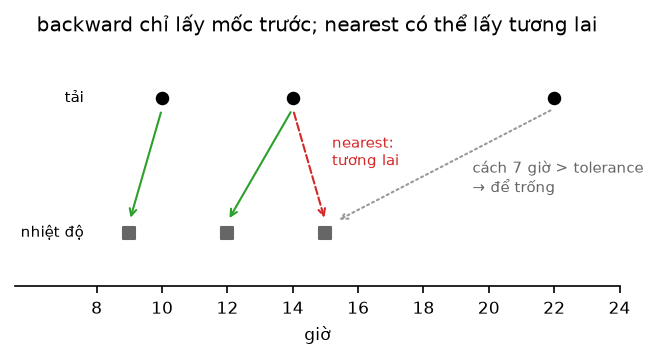

> **point-in-time** · *point-in-time data*
>
> - **Là gì:** số liệu đúng như nó có ở từng thời điểm công bố, không phải bản đã sửa về sau.
> - **Ví dụ:** doanh số tháng 3/2019 công bố lần đầu 100, năm 2021 sửa thành 103 (số minh hoạ): backtest cho năm 2019 phải dùng 100.
> - **Để làm gì:** backtest bằng bản đã sửa là rò rỉ, kết quả lạc quan hơn thực tế.

**Lý do.** Cái giá của rò rỉ bằng khoảng cách chất lượng giữa sự thật và thứ bạn thật sự có. Đo nó: cùng một hồi quy tuyến tính trên lag
và giờ, thêm lần lượt từng nguồn nhiệt độ của giờ cần dự báo. Thêm kịch bản hay gặp nhất: huấn luyện bằng nhiệt độ thật (lịch sử có sẵn),
chạy thật bằng bản dự báo.

**Kết quả.** Bản dự báo nhiệt độ sai bao nhiêu, và bảng giá của rò rỉ (học 70% đầu năm 2024, kiểm 30% cuối):

In [ ]:
sai = tt.dropna()
print(f"MAE dự báo nhiệt độ: trước 1 ngày {(sai['du_bao_1_ngay'] - sai['nhiet_do_that']).abs().mean():.3f} °C, "
      f"trước 3 ngày {(sai['du_bao_3_ngay'] - sai['nhiet_do_that']).abs().mean():.3f} °C ({len(sai):,} giờ)")

TAM = 24
d = chuoi_tai().rename("phu_tai").to_frame().join(tt, how="inner").dropna(subset=["phu_tai"])
d["muc_tieu"] = d["phu_tai"].shift(-TAM)                            # tải của giờ t + 24
d["lag_24"], d["lag_168"] = d["phu_tai"], d["phu_tai"].shift(144)   # so với giờ cần dự báo: trễ 24 và 168 giờ
d["gio_sin"], d["gio_cos"] = np.sin(2 * np.pi * d.index.hour / 24), np.cos(2 * np.pi * d.index.hour / 24)
for c in ("nhiet_do_that", "du_bao_1_ngay", "du_bao_3_ngay"):
    d[f"{c}_muc_tieu"] = d[c].shift(-TAM)                           # nhiệt độ ở ĐÚNG giờ cần dự báo, theo từng nguồn
NEN = ["lag_24", "lag_168", "gio_sin", "gio_cos"]


def mae(cot_hoc, cot_chay=None, ty_le_hoc=0.7):
    cot_chay = cot_chay or cot_hoc
    bang = d[list(dict.fromkeys(cot_hoc + cot_chay)) + ["muc_tieu"]].dropna()
    hoc, kiem = bang.iloc[:int(len(bang) * ty_le_hoc)], bang.iloc[int(len(bang) * ty_le_hoc):]
    return np.mean(np.abs(hoi_quy(hoc[cot_hoc], hoc["muc_tieu"], kiem[cot_chay]) - kiem["muc_tieu"].to_numpy(float)))


gia = pd.Series({
    "chỉ lag + giờ": mae(NEN),
    "+ nhiệt độ THẬT của giờ cần dự báo (rò rỉ)": mae(NEN + ["nhiet_do_that_muc_tieu"]),
    "+ dự báo nhiệt độ trước 1 ngày": mae(NEN + ["du_bao_1_ngay_muc_tieu"]),
    "+ dự báo nhiệt độ trước 3 ngày": mae(NEN + ["du_bao_3_ngay_muc_tieu"]),
    "+ nhiệt độ HIỆN TẠI (nhân quả)": mae(NEN + ["nhiet_do_that"]),
    "học bằng thật, CHẠY bằng dự báo 1 ngày": mae(NEN + ["nhiet_do_that_muc_tieu"], NEN + ["du_bao_1_ngay_muc_tieu"]),
    "học bằng thật, CHẠY bằng dự báo 3 ngày": mae(NEN + ["nhiet_do_that_muc_tieu"], NEN + ["du_bao_3_ngay_muc_tieu"]),
})
print(pd.DataFrame({"MAE (MW)": gia.round(2), "so với chỉ lag": (gia / gia.iloc[0] - 1).map("{:+.2%}".format)}).to_string())

Bản dự báo trước 1 ngày sai trung bình 1,3 °C, trước 3 ngày 2,1 °C. Backtest bằng nhiệt độ thật hứa giảm 3,85% sai số. Huấn luyện
bằng thật rồi chạy bằng dự báo trước 1 ngày còn −3,10%; chạy bằng dự báo trước 3 ngày thì **tăng** 2,20% — tệ hơn không dùng nhiệt độ.
Huấn luyện bằng chính bản dự báo 1 ngày (−3,95%) còn tốt hơn dùng sự thật một chút, vì mô hình học đúng loại đầu vào sẽ gặp; bản 3 ngày
kém tới mức huấn luyện bằng nó vẫn thua (+2,92%).

Khi biến ngoại sinh đến ở mốc lệch, ghép bằng `merge_asof`. Bảng tải lúc 10, 14, 22 giờ; bản tin nhiệt độ lúc 9, 12, 15 giờ:

In [ ]:
trai = pd.DataFrame({"tai": [40, 45, 42]}, index=pd.to_datetime(["2024-07-01 10:00", "2024-07-01 14:00", "2024-07-01 22:00"]))
phai = pd.DataFrame({"nhiet": [28.0, 33.0, 36.0]}, index=pd.to_datetime(["2024-07-01 09:00", "2024-07-01 12:00", "2024-07-01 15:00"]))
kieu = {"backward": {"direction": "backward"}, "nearest": {"direction": "nearest"},
        "backward + tolerance 3h": {"direction": "backward", "tolerance": pd.Timedelta("3h")}}
print(pd.DataFrame({ten: pd.merge_asof(trai, phai, left_index=True, right_index=True, **tham_so)["nhiet"]
                    for ten, tham_so in kieu.items()}).to_string())

`nearest` ghép giờ 14 với bản tin 15 giờ (36 °C) — một giờ trong tương lai. `backward` không đặt `tolerance` kéo bản tin 15 giờ xuống
giờ 22 mà không báo; có `tolerance` thì để trống, lộ ra chỗ nguồn bị thiếu. Còn một chỗ lệch mốc nữa: EIA-930 ghi mốc **cuối** giờ,
Open-Meteo ghi mốc **đầu** giờ. Số liệu hay bị sửa sau khi công bố (GDP, doanh số) thì dùng bản point-in-time, không có thì lùi mốc dùng
đúng bằng độ trễ công bố.

**Bài học.** Biến ngoại sinh phải là thứ có trong tay lúc dự báo: bản dự báo, không phải giá trị thật. Huấn luyện bằng đúng loại dữ liệu
sẽ gặp lúc chạy; ghép bằng `merge_asof(direction="backward", tolerance=...)`.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Quét $K$ Fourier.** Lượt xem Wikipedia, bộ feature đầy đủ, đổi số cặp Fourier:

In [ ]:
for K in (1, 2, 3, 5, 10):
    so_cot, mae_ca_nam, _ = mae_wiki(bo_feature(wiki, k=K))
    print(f"K = {K:>2} ({so_cot} feature): MAE {mae_ca_nam:,.0f}")

$K$ = 3 tốt nhất (MAE 129.680), $K$ = 2 gần bằng; từ $K$ = 5 sai số tăng lại, tới 131.069 ở $K$ = 10. Sóng bậc cao lặp nhiều lần
mỗi năm, đủ uốn theo những gợn ngẫu nhiên của phần học — học thuộc nhiễu — mà các gợn đó không lặp lại ở phần kiểm.

**Bài 2 — Rò rỉ tinh vi.** "Trung bình 7 ngày của cùng mã hàng trên toàn bộ dữ liệu" là một con số tính trên cả chuỗi. Nếu nó được
tính **bên trong** hàm tạo feature, bài cắt tương lai bắt được (như `tb_theo_thu` ở phần 5). Nếu tính sẵn một lần ở ngoài rồi ghép vào
như bảng tra, thì cắt dữ liệu không làm nó đổi, và bài kiểm im lặng. Minh hoạ trên chuỗi doanh thu với trung bình theo thứ:

In [ ]:
tb_thu_ca_chuoi = y.groupby(y.index.dayofweek).mean()                 # tính MỘT LẦN trên cả chuỗi, ở ngoài hàm


def feature_tra_bang(s):
    return pd.DataFrame({"tb_theo_thu_tra_bang": s.index.dayofweek.map(tb_thu_ca_chuoi).to_numpy(float)}, index=s.index)


print("tính trong hàm :", kiem_ro_ri(lambda s: s.groupby(s.index.dayofweek).transform("mean").rename("tb_theo_thu").to_frame(), y))
print("tra bảng ngoài :", kiem_ro_ri(feature_tra_bang, y), "| nhiễu mục tiêu:", kiem_nhieu_muc_tieu(feature_tra_bang, y))

Cả hai bài kiểm tự động đều im lặng với bản tra bảng, vì hàm tạo feature không nhìn thấy dữ liệu gốc. Chỉ **bảng biết trước bao lâu**
bắt được: hỏi "bảng tra này tính trên những ngày nào?" — trả lời "cả chuỗi" là rò rỉ. Sửa: tính bảng tra chỉ từ các ngày trước $t$.

**Bài 3 — Point-in-time.** EIA-930 có cột `Demand (MW)` (bản thô) và `Demand (MW) (Adjusted)` (bản đã sửa, điền thay các giờ lỗi; cột
`Imputed` chỉ ghi các giờ bị điền). Đếm số giờ khác nhau, rồi backtest mô hình chỉ lag + giờ trên cả hai bản:

In [ ]:
def mae_lag(s, ty_le_hoc=0.7):
    b = pd.DataFrame({"muc_tieu": s.shift(-TAM), "lag_24": s, "lag_168": s.shift(144),
                      "gio_sin": np.sin(2 * np.pi * s.index.hour / 24), "gio_cos": np.cos(2 * np.pi * s.index.hour / 24)}).dropna()
    hoc, kiem = b.iloc[:int(len(b) * ty_le_hoc)], b.iloc[int(len(b) * ty_le_hoc):]
    return np.mean(np.abs(hoi_quy(hoc[NEN], hoc["muc_tieu"], kiem[NEN]) - kiem["muc_tieu"].to_numpy(float)))


for vung in ("ERCO", "WALC"):
    tho, sua = chuoi_tai(vung), chuoi_tai(vung, "Demand (MW) (Adjusted)")
    print(f"{vung}: {int(((tho - sua).abs() > 0.5).sum())} giờ khác nhau | MAE bản thô {mae_lag(tho):,.2f}, bản đã sửa {mae_lag(sua):,.2f}")

Với ERCOT năm 2024, bản thô và bản đã sửa trùng khít, hai backtest bằng nhau: không có gì để chênh. Vùng WALC (Arizona) có 37 giờ
bản thô ghi sai hẳn (âm tới hàng trăm nghìn MW), bản đã sửa thay bằng số hợp lý; MAE 736,28 so với 54,40. Lúc chạy thật mô hình nhận
bản thô, nên con số trung thực là backtest trên bản thô sau bước làm sạch mà bạn tự làm được lúc đó. Con số trên bản đã sửa chỉ báo kèm,
ghi rõ là lạc quan.

## Tự kiểm

- [ ] Xếp được feature "dự báo mưa ngày mai" và "số khách ngày mai của quán bên cạnh" vào nhóm biết trước, hoặc loại.
- [ ] Chỉ ra ô nhìn trộm của `y.rolling(3)` và `y.rolling(3, center=True)` trên bảng 6 ngày.
- [ ] Nói vì sao `y.shift(1).rolling(28)` không hợp lệ khi dự báo trước 7 ngày.
- [ ] Tính cos của tháng 12 và tháng 1, và nói vì sao cần thêm sin.
- [ ] Nói bốn chi tiết làm bài kiểm cắt tương lai có tác dụng, và lỗi nào chỉ bài nhiễu mục tiêu bắt được.
- [ ] Giải thích vì sao huấn luyện bằng nhiệt độ thật rồi chạy bằng dự báo 3 ngày lại tệ hơn chỉ dùng lag.